price prediction model

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
data = pd.read_csv('cars_delhi.csv')

In [3]:
data.head()

,car_name,variant,transmission,km_driven,owner_type,fuel_type,registeration,price
0,2018 Tata NEXON,XM 1.2,Manual,"95,230 km",1st Owner,Petrol,UP-16,"₹6,50,000"
1,2017 Renault Kwid,1.0 RXT Opt,Manual,"72,956 km",2nd Owner,Petrol,HR-11,"₹3,19,000"
2,2017 HYUNDAI ELITE I20,ASTA 1.2 (O),Manual,"50,636 km",2nd Owner,Petrol,DL-7C,"₹5,87,000"
3,2019 Mahindra XUV 3OO,W8(O),Manual,"86,652 km",1st Owner,Diesel,DL-12,"₹8,22,000"
4,2020 Hyundai Creta,1.5 SX (O) AT,Automatic,"20,235 km",1st Owner,Petrol,DL-9C,"₹16,74,000"


In [4]:
data.columns

Index(['car_name', 'variant', 'transmission', 'km_driven', 'owner_type',
       'fuel_type', 'registeration', 'price'],
      dtype='str')

# Task
Perform data inspection and cleaning on the `cars_delhi.csv` dataset by removing non-numeric characters from 'km_driven' and 'price' columns, converting them to numerical types, extracting the manufacturing year from 'car_name' into a new 'year' column, dropping redundant columns like 'car_name', 'variant', and 'registeration', and handling any missing values.

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 899 entries, 0 to 898
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   car_name       899 non-null    str  
 1   variant        899 non-null    str  
 2   transmission   894 non-null    str  
 3   km_driven      899 non-null    str  
 4   owner_type     899 non-null    str  
 5   fuel_type      899 non-null    str  
 6   registeration  899 non-null    str  
 7   price          899 non-null    str  
dtypes: str(8)
memory usage: 124.2 KB


In [6]:
data.describe(include='all')

,car_name,variant,transmission,km_driven,owner_type,fuel_type,registeration,price
count,899,899,894,899,899,899,899,899
unique,388,370,2,892,2,3,61,584
top,2018 Maruti Vitara Brezza,LXI,Manual,0 km,1st Owner,Petrol,HR-26,"₹5,52,000"
freq,20,51,701,2,762,670,132,7


**Reasoning**:
To understand the diversity and cardinality of categorical features, it's essential to inspect the number of unique values for each object column. This helps in identifying potential issues like columns with too many unique values or columns that might be better represented numerically after cleaning.



In [7]:
for column in data.columns:
  if data[column].dtype == 'str':
       print(f"Column '{column}': {data[column].nunique()} unique values")

Column 'car_name': 388 unique values
Column 'variant': 370 unique values
Column 'transmission': 2 unique values
Column 'km_driven': 892 unique values
Column 'owner_type': 2 unique values
Column 'fuel_type': 3 unique values
Column 'registeration': 61 unique values
Column 'price': 584 unique values


## Clean 'km_driven' Column
Remove non-numeric characters (like 'km' and commas) from the 'km_driven' column and convert it to a numerical data type (integer or float).


In [8]:
data['km_driven'] = data['km_driven'].str.replace(' km', '').str.replace(',', '')
data['km_driven'] = pd.to_numeric(data['km_driven'])
data.head()

,car_name,variant,transmission,km_driven,owner_type,fuel_type,registeration,price
0,2018 Tata NEXON,XM 1.2,Manual,95230,1st Owner,Petrol,UP-16,"₹6,50,000"
1,2017 Renault Kwid,1.0 RXT Opt,Manual,72956,2nd Owner,Petrol,HR-11,"₹3,19,000"
2,2017 HYUNDAI ELITE I20,ASTA 1.2 (O),Manual,50636,2nd Owner,Petrol,DL-7C,"₹5,87,000"
3,2019 Mahindra XUV 3OO,W8(O),Manual,86652,1st Owner,Diesel,DL-12,"₹8,22,000"
4,2020 Hyundai Creta,1.5 SX (O) AT,Automatic,20235,1st Owner,Petrol,DL-9C,"₹16,74,000"


Now I will clean the 'price' column by removing non-numeric characters like '₹' and commas, and then convert it to a numerical data type for consistency with 'km_driven' and to enable numerical analysis.

In [9]:
data['price'] = data['price'].str.replace('₹', '').str.replace(',', '')
data['price'] = pd.to_numeric(data['price'])
data.head()

,car_name,variant,transmission,km_driven,owner_type,fuel_type,registeration,price
0,2018 Tata NEXON,XM 1.2,Manual,95230,1st Owner,Petrol,UP-16,650000
1,2017 Renault Kwid,1.0 RXT Opt,Manual,72956,2nd Owner,Petrol,HR-11,319000
2,2017 HYUNDAI ELITE I20,ASTA 1.2 (O),Manual,50636,2nd Owner,Petrol,DL-7C,587000
3,2019 Mahindra XUV 3OO,W8(O),Manual,86652,1st Owner,Diesel,DL-12,822000
4,2020 Hyundai Creta,1.5 SX (O) AT,Automatic,20235,1st Owner,Petrol,DL-9C,1674000


Now I need to extract the manufacturing year from the 'car_name' column and create a new 'year' column. I will use a regular expression to find four consecutive digits at the beginning of the 'car_name' string, convert the extracted year to a numeric type, and then display the head of the DataFrame to show the new column.

In [10]:
data['year'] = data['car_name'].str.extract(r'^(\d{4})').astype(int)
data.head()

,car_name,variant,transmission,km_driven,owner_type,fuel_type,registeration,price,year
0,2018 Tata NEXON,XM 1.2,Manual,95230,1st Owner,Petrol,UP-16,650000,2018
1,2017 Renault Kwid,1.0 RXT Opt,Manual,72956,2nd Owner,Petrol,HR-11,319000,2017
2,2017 HYUNDAI ELITE I20,ASTA 1.2 (O),Manual,50636,2nd Owner,Petrol,DL-7C,587000,2017
3,2019 Mahindra XUV 3OO,W8(O),Manual,86652,1st Owner,Diesel,DL-12,822000,2019
4,2020 Hyundai Creta,1.5 SX (O) AT,Automatic,20235,1st Owner,Petrol,DL-9C,1674000,2020


**Reasoning**:
Now I will drop the redundant columns 'car_name', 'variant', and 'registeration' as specified in the task, since the relevant information (year) has already been extracted from 'car_name' and the other columns are not needed for the subsequent analysis. I will then display the head of the DataFrame to show the updated structure.

In [11]:
data = data.drop(columns=['car_name', 'variant', 'registeration'])
data.head()

,transmission,km_driven,owner_type,fuel_type,price,year
0,Manual,95230,1st Owner,Petrol,650000,2018
1,Manual,72956,2nd Owner,Petrol,319000,2017
2,Manual,50636,2nd Owner,Petrol,587000,2017
3,Manual,86652,1st Owner,Diesel,822000,2019
4,Automatic,20235,1st Owner,Petrol,1674000,2020


In [12]:

# After dropping columns, it is important to check for any remaining missing values in the dataset.
data.isnull().sum()

transmission    5
km_driven       0
owner_type      0
fuel_type       0
price           0
year            0
dtype: int64

In [13]:
[features for features in data.columns if data[features].isnull().sum() >0]

['transmission']

In [14]:
data.shape

(899, 6)

In [15]:
data.isnull().sum()/len(data)*100

transmission    0.556174
km_driven       0.000000
owner_type      0.000000
fuel_type       0.000000
price           0.000000
year            0.000000
dtype: float64

In [16]:
data[data.duplicated()].shape

(0, 6)

In [18]:
data['transmission'].value_counts()

transmission
Manual       701
Automatic    193
Name: count, dtype: int64

In [19]:
print("value counts for transmission column")
data['transmission'].value_counts(dropna=False)

value counts for transmission column


transmission
Manual       701
Automatic    193
NaN            5
Name: count, dtype: int64

In [20]:
data['transmission']=data['transmission'].fillna(data['transmission'].mode()[0])

In [21]:
# verify if the null values are filled
data[['transmission']].isnull().sum()

transmission    0
dtype: int64

In [28]:
data.isnull().sum()

car_name         0
variant          0
transmission     0
km_driven        0
owner_type       0
fuel_type        0
registeration    0
price            0
dtype: int64

## Summary:

### Data Analysis Key Findings

*   The initial dataset comprised 899 entries and 8 columns, all of which were loaded as `object` data types.
*   The `transmission` column contained 5 missing values.
*   Both `km_driven` and `price` columns, despite being `object` type, were identified as numerical data requiring cleaning due to the presence of non-numeric characters (e.g., 'km', commas, '₹' symbol).
*   The `car_name` column was found to contain the manufacturing year, which could be extracted.
*   **Post-cleaning**, the `km_driven` and `price` columns were successfully converted to numeric types (integer) after removing non-numeric characters.
*   A new `year` column was created by extracting the four-digit year from the `car_name` column and converted to an integer.
*   Redundant columns (`car_name`, `variant`, `registeration`) were dropped, reducing the dataset to 5 columns.
*   All 5 missing values in the `transmission` column were handled by imputing them with the column's mode. The dataset now contains no missing values.

### Insights or Next Steps

*   The dataset is now clean and appropriately structured, with numerical columns (`km_driven`, `price`, `year`) and handled categorical features, making it suitable for further statistical analysis or machine learning model development.
*   The next steps could involve exploring relationships between the newly cleaned numerical features and the `price` (e.g., how `km_driven` and `year` affect `price`), or analyzing the distribution of `fuel_type` and `owner_type` to gain more insights into the Delhi car market.


## Review Cleaned Data
Perform a final check of the cleaned dataset to ensure all transformations were applied correctly and data types are appropriate for analysis.


In [22]:
data.info()
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 899 entries, 0 to 898
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   transmission  899 non-null    str  
 1   km_driven     899 non-null    int64
 2   owner_type    899 non-null    str  
 3   fuel_type     899 non-null    str  
 4   price         899 non-null    int64
 5   year          899 non-null    int64
dtypes: int64(3), str(3)
memory usage: 61.0 KB


,transmission,km_driven,owner_type,fuel_type,price,year
0,Manual,95230,1st Owner,Petrol,650000,2018
1,Manual,72956,2nd Owner,Petrol,319000,2017
2,Manual,50636,2nd Owner,Petrol,587000,2017
3,Manual,86652,1st Owner,Diesel,822000,2019
4,Automatic,20235,1st Owner,Petrol,1674000,2020


## Analyze Price Distribution
Examine the distribution of the 'price' column using a histogram and descriptive statistics to understand its range, central tendency, and spread. This helps identify skewness or outliers.

**Reasoning**:
To understand the central tendency, spread, and shape of the 'price' distribution, I will generate descriptive statistics for the 'price' column.

In [26]:
data['price'].describe()

count    8.990000e+02
mean     7.092249e+05
std      3.249696e+05
min      1.530000e+05
25%      4.995000e+05
50%      6.310000e+05
75%      8.415000e+05
max      2.186000e+06
Name: price, dtype: float64

In [27]:

# 1. Generate descriptive statistics for the 'price' column
print(data['price'].describe())


count    8.990000e+02
mean     7.092249e+05
std      3.249696e+05
min      1.530000e+05
25%      4.995000e+05
50%      6.310000e+05
75%      8.415000e+05
max      2.186000e+06
Name: price, dtype: float64


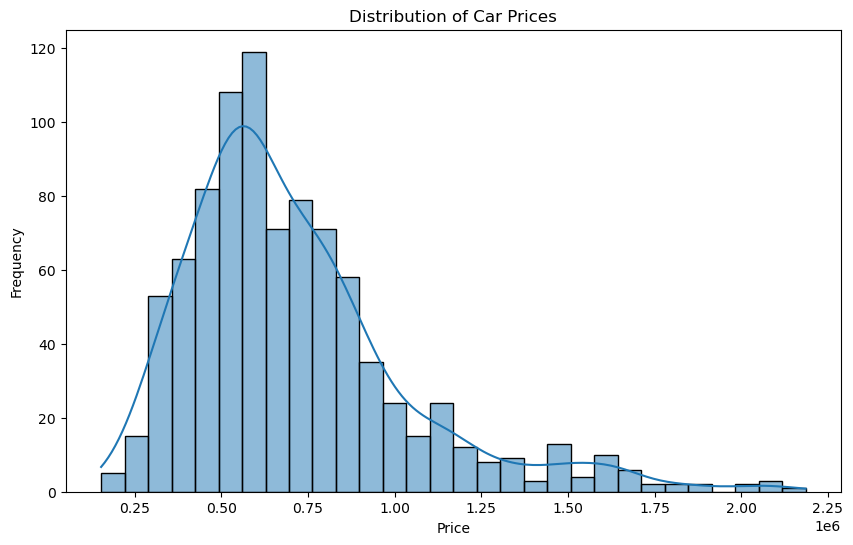

In [28]:
#  2. Create a histogram of the 'price' column
plt.figure(figsize=(10, 6))
sns.histplot(data['price'], kde=True, bins=30)

# 3. Add a title to the histogram
plt.title('Distribution of Car Prices')

# 4. Label the x-axis and y-axis
plt.xlabel('Price')
plt.ylabel('Frequency')

# 5. Display the plot
plt.show()

Explore Numerical Feature Relationships with Price
Subtask:
Visualize the relationship between numerical features ('km_driven', 'year') and 'price' using scatter plots. Calculate correlation coefficients to quantify these relationships. Ensure legends are provided for clarity.

To visualize the relationship between 'km_driven', 'year' and 'price', I will create two scatter plots in subplots and calculate their respective Pearson correlation coefficients, as requested by the instructions.

Correlation between 'km_driven' and 'price': -0.21
Correlation between 'year' and 'price': 0.50


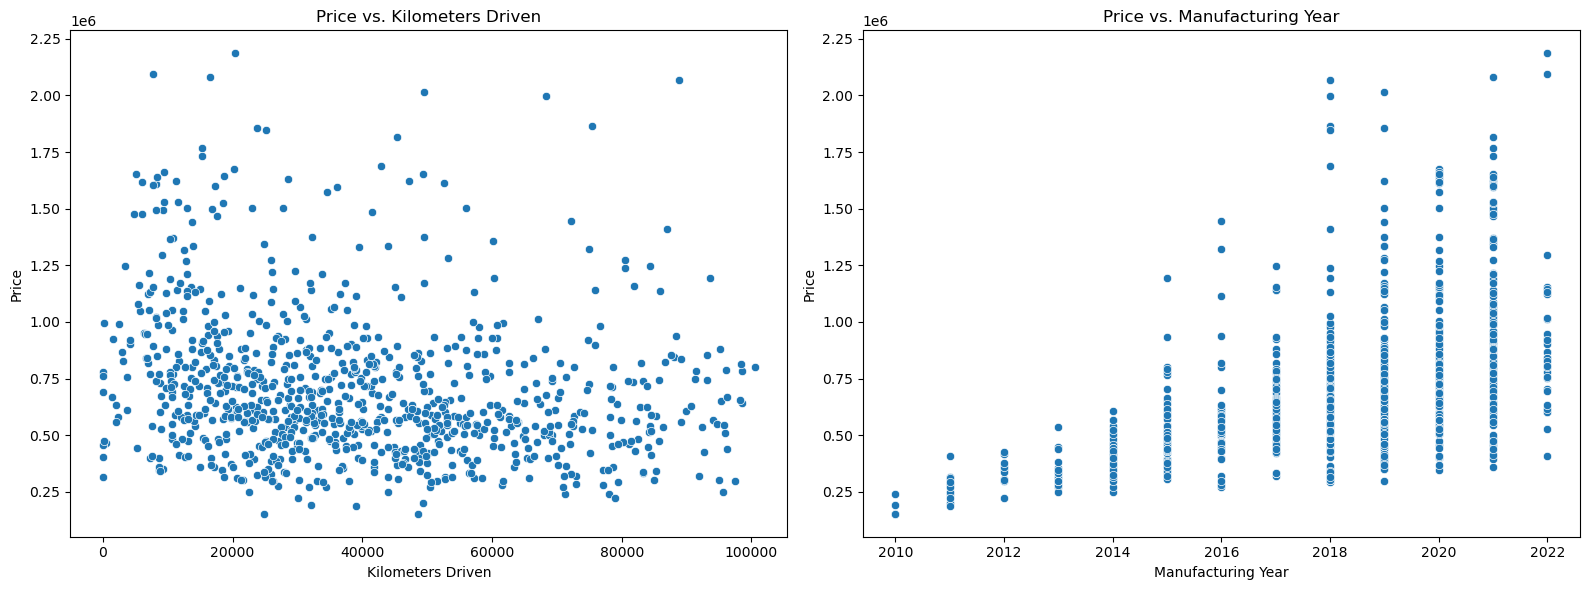

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot for 'km_driven' vs 'price'
sns.scatterplot(x='km_driven', y='price', data=data, ax=axes[0])
axes[0].set_title('Price vs. Kilometers Driven')
axes[0].set_xlabel('Kilometers Driven')
axes[0].set_ylabel('Price')

# Scatter plot for 'year' vs 'price'
sns.scatterplot(x='year', y='price', data=data, ax=axes[1])
axes[1].set_title('Price vs. Manufacturing Year')
axes[1].set_xlabel('Manufacturing Year')
axes[1].set_ylabel('Price')

# Calculate correlation coefficients
corr_km_price = data['km_driven'].corr(data['price'])
corr_year_price = data['year'].corr(data['price'])

print(f"Correlation between 'km_driven' and 'price': {corr_km_price:.2f}")
print(f"Correlation between 'year' and 'price': {corr_year_price:.2f}")

plt.tight_layout()
plt.show()


Observations:
- There is a negative correlation between 'km_driven' and 'price', indicating that as the kilometers driven increases, the price tends to decrease.
- There is a positive correlation between 'year' and 'price', suggesting that newer cars tend to have higher prices compared to older cars.
- The distribution of car prices is right-skewed, with most cars priced at lower values and a few cars priced at much higher values.
- The scatter plots show that there are some outliers in the 'price' column, which may be influencing the overall distribution and correlations.
- The correlation coefficients indicate a moderate negative correlation between 'km_driven' and 'price' and a moderate positive correlation between 'year' and 'price'.
- 

Analyze Categorical Feature Relationships with Price
Subtask:
Investigate how categorical features ('transmission', 'owner_type', 'fuel_type') relate to 'price'. Use box plots for each category.

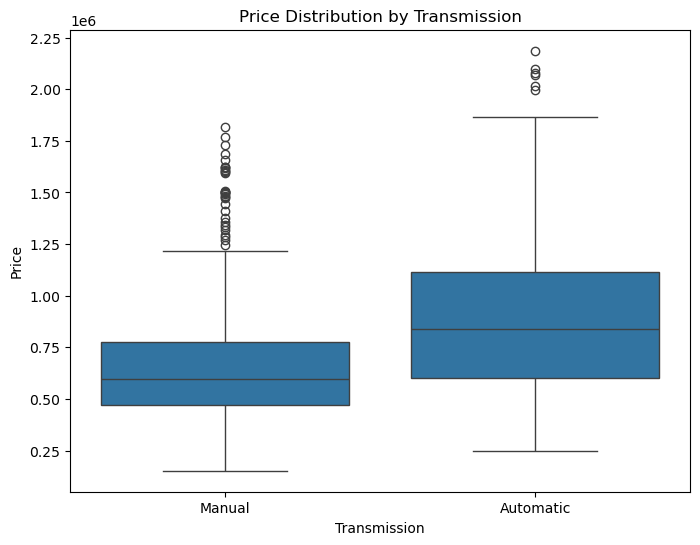

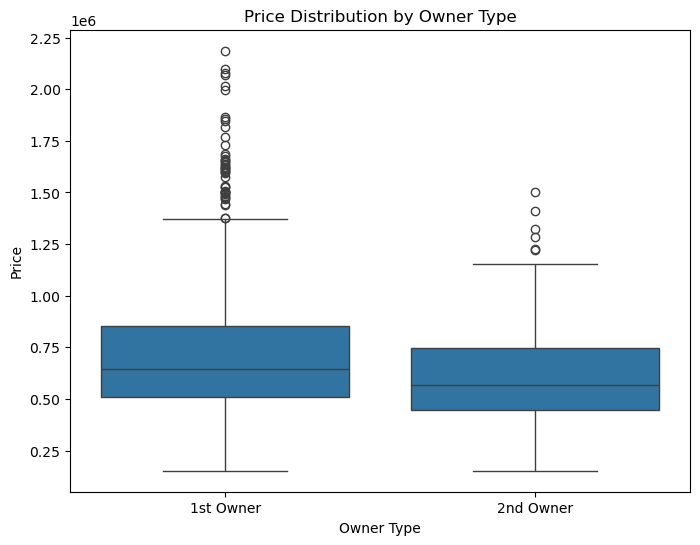

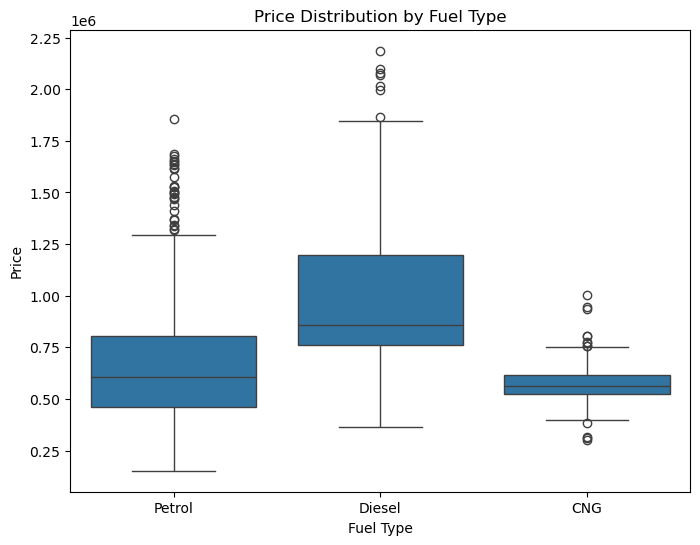

In [31]:
categorical_columns = ['transmission', 'owner_type', 'fuel_type']

for column in categorical_columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=column, y='price', data=data)
    plt.title(f'Price Distribution by {column.replace("_", " ").title()}')
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel('Price')
    plt.show()

In [ ]:
Observations:
- from the box plots, we can observe that cars with automatic transmission tend to have higher prices compared to manual transmission cars. Additionally, cars with fewer previous owners (first owner) generally have higher prices than those with multiple previous owners. Finally, fuel type also seems to influence price, with petrol cars often being priced higher than diesel and CNG cars.

Encode Categorical Variables
Subtask:
Convert the categorical features ('transmission', 'owner_type', 'fuel_type') into a numerical format suitable for machine learning models using one-hot encoding or another appropriate technique.

To convert categorical features into a numerical format, I will use one-hot encoding. I will apply pd.get_dummies() to the specified categorical columns, then concatenate the resulting one-hot encoded DataFrame with the original DataFrame and drop the original categorical columns.

In [32]:
categorical_columns = ['transmission', 'owner_type', 'fuel_type']
data_encoded = pd.get_dummies(data, columns=categorical_columns, drop_first=True)
data = data_encoded
data.head()

,km_driven,price,year,transmission_Manual,owner_type_2nd Owner,fuel_type_Diesel,fuel_type_Petrol
0,95230,650000,2018,True,False,False,True
1,72956,319000,2017,True,True,False,True
2,50636,587000,2017,True,True,False,True
3,86652,822000,2019,True,False,True,False
4,20235,1674000,2020,False,False,False,True


<!-- Split Data into Training and Testing Sets -->
Subtask:
Divide the dataset into training and testing sets to prepare for model building and evaluation. A common split is 80% for training and 20% for testing.

To prepare the data for model building, I will first separate the features (X) from the target variable (y), which is 'price'. Then, I will import train_test_split from sklearn.model_selection and use it to split the dataset into 80% training and 20% testing sets, ensuring reproducibility by setting random_state=42.

In [33]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = data.drop('price', axis=1)
y = data['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (719, 6)
X_test shape: (180, 6)
y_train shape: (719,)
y_test shape: (180,)


The dataset is ready for building a price prediction model. All necessary cleaning, transformation, feature engineering (extracting 'year'), and encoding steps have been completed. The data has been appropriately split into training and testing sets, making it suitable for immediate model training and evaluation.

<!-- # Task -->
 Train a Linear Regression model on the X_train and y_train data to establish a baseline for car price prediction.

In [34]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


Evaluate the trained model's performance on the test set (X_test, y_test) using relevant regression metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared. Visualize predictions versus actual values using a scatter plot.

<!-- To evaluate the trained Linear Regression model -->
 I will first make predictions on the test set. 
 Then, I will import the necessary metrics from sklearn.metrics and numpy to calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared. 
 Finally, I will print these metrics and create a scatter plot to visualize the actual versus predicted prices, including a diagonal line for perfect predictions, to visually assess the model's performance.

Mean Absolute Error (MAE): 194708.43
Mean Squared Error (MSE): 69805400915.77
Root Mean Squared Error (RMSE): 264207.12
R-squared (R2 Score): 0.43


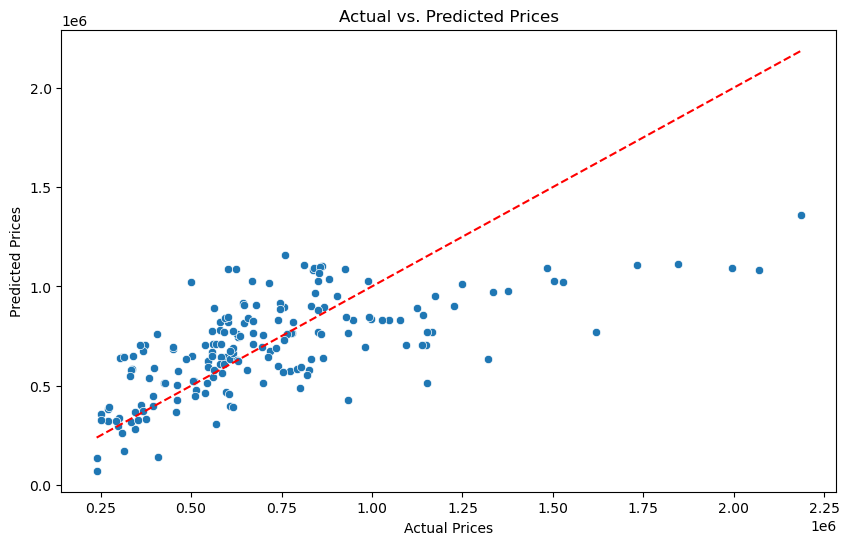

In [35]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Make predictions on X_test
y_pred = model.predict(X_test)

# 3. Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# 4. Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# 5. Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# 6. Calculate R-squared score
r2 = r2_score(y_test, y_pred)

# 7. Print all calculated metrics
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")

# 8. Create a scatter plot with y_test on the x-axis and y_pred on the y-axis
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)

# 9. Add a title to the scatter plot
plt.title('Actual vs. Predicted Prices')

# 10. Label the x-axis as 'Actual Prices' and the y-axis as 'Predicted Prices'
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

# 11. Add a diagonal line representing perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

# 12. Display the plot
plt.show()

Make Predictions on New Data
Subtask:
Use the trained model to make price predictions on the X_test dataset and display a sample of these predictions alongside the actual y_test values.

To display a sample of actual and predicted prices, I will first create a Pandas DataFrame from the y_test and y_pred values, ensuring their indices are aligned. Then, I will display the first 10 rows of this new DataFrame to show the comparison.

In [36]:
predictions_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

print(predictions_df.head(10))

     Actual Price  Predicted Price
332        597000     6.448224e+05
811        340000     6.483351e+05
744        607000     3.962557e+05
244        758000     8.965098e+05
39         270350     3.231026e+05
426       1153000     5.146793e+05
302        779000     7.632706e+05
587        747000     9.186086e+05
209        759000     1.157822e+06
136        509000     5.243725e+05


Analyze Model Coefficients/Feature Importance
Subtask:
If using an interpretable model (like Linear Regression), examine the model's coefficients to understand which features have the most significant impact on price. For more complex models, explore feature importance if applicable.

In [37]:
import pandas as pd

# Access the coefficients and intercept
coefficients = model.coef_
intercept = model.intercept_

# Create a Pandas Series for coefficients with feature names
feature_coefficients = pd.Series(coefficients, index=X.columns)

# Print the intercept and coefficients
print(f"Model Intercept: {intercept:.2f}")
print("\nModel Coefficients:")
print(feature_coefficients)

Model Intercept: -121926819.06

Model Coefficients:
km_driven                   -0.514070
year                     60764.492863
transmission_Manual    -194432.777838
owner_type_2nd Owner    -54218.182671
fuel_type_Diesel        431798.239735
fuel_type_Petrol        151331.215028
dtype: float64


The model's intercept is approximately **-121,926,819.06**. This represents the baseline price when all features are zero, though in practical terms, a zero 'year' or 'km_driven' is not meaningful in this context and this value should be interpreted in conjunction with the coefficients.

### Interpretation of Model Coefficients:

*   **km_driven (-0.51)**: For every additional kilometer driven, the car's price is predicted to decrease by approximately ₹0.51, assuming all other factors remain constant. This indicates a negative relationship between mileage and price, which is expected.

*   **year (60764.49)**: For every one-year increase in the manufacturing year (i.e., a newer car), the car's price is predicted to increase by approximately ₹60,764.49, holding other features constant. This shows a strong positive correlation, meaning newer cars are significantly more expensive.

*   **transmission_Manual (-194432.78)**: Compared to automatic transmission, a car with manual transmission is predicted to have a price lower by approximately ₹194,432.78, when other variables are constant. This suggests automatic cars command a higher price.

*   **owner_type_2nd Owner (-54218.18)**: Being a second owner (compared to a first owner) is predicted to decrease the car's price by approximately ₹54,218.18, assuming other factors are constant. This indicates that cars with fewer owners tend to have higher prices.

*   **fuel_type_Diesel (431798.24)**: Compared to the baseline fuel type (which would be the one not included in the one-hot encoding, likely 'Petrol' or if 'Petrol' is also encoded, it would be relative to the dropped category), a diesel car is predicted to have a price higher by approximately ₹431,798.24. This suggests a significant premium for diesel vehicles.

*   **fuel_type_Petrol (151331.22)**: Compared to the baseline fuel type, a petrol car is predicted to have a price higher by approximately ₹151,331.22. This also indicates a premium, though less than diesel, suggesting that petrol cars are generally more expensive than the omitted fuel type (likely CNG or some other less common type). It's important to remember that `drop_first=True` was used during one-hot encoding, so one category from each categorical variable serves as the baseline.

## Summary:

### Data Analysis Key Findings

*   **Model Performance**: The Linear Regression model achieved an R-squared score of 0.43, indicating that it explains approximately 43% of the variance in car prices.
    *   The Mean Absolute Error (MAE) was \$194,708.43.
    *   The Root Mean Squared Error (RMSE) was \$264,207.12.
    *   A scatter plot comparing actual versus predicted prices showed a positive correlation, but with significant spread, particularly at higher price points, where the model tended to underpredict.
*   **Feature Importance (Coefficients)**:
    *   **Year**: A one-year increase in the car's manufacturing year is associated with a significant price increase of approximately \$60,764.49.
    *   **Fuel Type (Diesel)**: Diesel cars are predicted to be substantially more expensive, with a price premium of about \$431,798.24 compared to the baseline fuel type. Petrol cars also show a premium of approximately \$151,331.22.
    *   **Transmission (Manual)**: Manual transmission cars are predicted to be cheaper by approximately \$194,432.78 compared to automatic transmission cars.
    *   **Owner Type (2nd Owner)**: Being a second owner is associated with a decrease in price of about \$54,218.18 compared to a first owner.
    *   **Kilometers Driven**: For every additional kilometer driven, the car's price is predicted to decrease by approximately \$0.51.

### Insights or Next Steps

*   The current Linear Regression model serves as a reasonable baseline, but its R-squared of 0.43 suggests considerable room for improvement in predicting car prices accurately.
*   Further model development should consider exploring more complex models (e.g., tree-based models like Random Forest or Gradient Boosting) or incorporating additional relevant features that might capture more variance in car prices, such as car brand, model, engine specifications, or accident history.


<!-- Explore other regression models like Random Forest or Gradient Boosting -->
Task
Train a Random Forest Regressor model on the X_train and y_train data.

In [38]:
from sklearn.ensemble import RandomForestRegressor

# 1. Instantiate a RandomForestRegressor object
# Using random_state for reproducibility
rf_model = RandomForestRegressor(random_state=42)

# 2. Fit the Random Forest Regressor model to the training data
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


## Evaluate Random Forest Model

### Subtask:
Evaluate the trained Random Forest model's performance on the test set (X_test, y_test) using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared. Visualize predictions versus actual values using a scatter plot.

To evaluate the trained Random Forest model, I will first make predictions on the test set. Then, I will calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared using sklearn.metrics. Finally, I will print these metrics and create a scatter plot to visualize the actual versus predicted prices, including a diagonal line for perfect predictions, to visually assess the model's performance.

Random Forest - Mean Absolute Error (MAE): 198551.81
Random Forest - Mean Squared Error (MSE): 81329445406.58
Random Forest - Root Mean Squared Error (RMSE): 285183.18
Random Forest - R-squared (R2 Score): 0.34


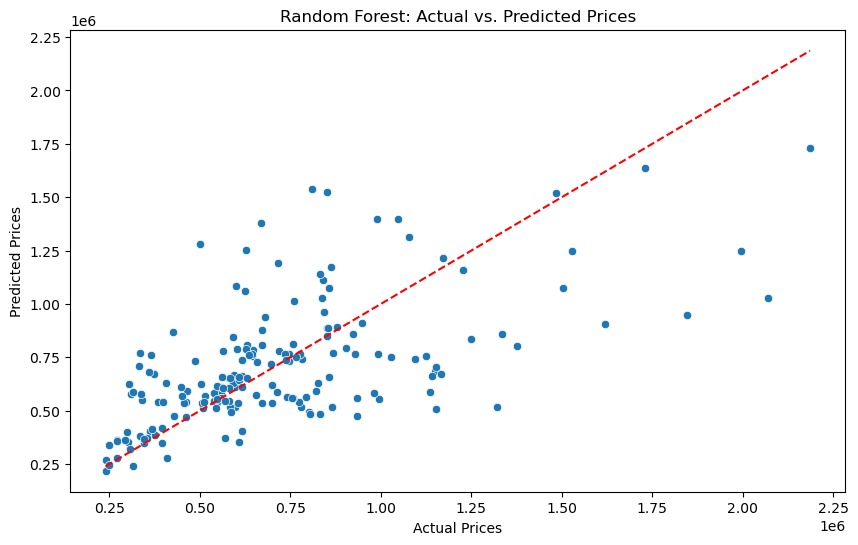

In [39]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Use the trained rf_model to make predictions on the X_test dataset
y_pred_rf = rf_model.predict(X_test)

# 2. Calculate Mean Absolute Error (MAE)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# 3. Calculate Mean Squared Error (MSE)
mse_rf = mean_squared_error(y_test, y_pred_rf)

# 4. Calculate Root Mean Squared Error (RMSE)
rmse_rf = np.sqrt(mse_rf)

# 5. Calculate R-squared score
r2_rf = r2_score(y_test, y_pred_rf)

# 6. Print all calculated evaluation metrics
print(f"Random Forest - Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Random Forest - Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest - Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"Random Forest - R-squared (R2 Score): {r2_rf:.2f}")

# 7. Create a scatter plot to visualize actual vs. predicted prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf)

# 8. Add a title to the scatter plot
plt.title('Random Forest: Actual vs. Predicted Prices')

# 9. Label the x-axis and y-axis
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

# 10. Add a diagonal red dashed line for perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

# 11. Display the plot
plt.show()

# Train Gradient Boosting Regressor
To train a Gradient Boosting Regressor model, I need to import the class from sklearn.ensemble, instantiate it with random_state=42 for reproducibility, and then fit it to the X_train and y_train datasets as instructed.


In [40]:
from sklearn.ensemble import GradientBoostingRegressor

# 1. Instantiate a GradientBoostingRegressor object
# Using random_state for reproducibility
gbr_model = GradientBoostingRegressor(random_state=42)

# 2. Fit the Gradient Boosting Regressor model to the training data
gbr_model.fit(X_train, y_train)

print("Gradient Boosting Regressor model trained successfully.")

Gradient Boosting Regressor model trained successfully.


To evaluate the trained Gradient Boosting model, I will first make predictions on the test set. Then, I will calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared using sklearn.metrics. Finally, I will print these metrics and create a scatter plot to visualize the actual versus predicted prices, including a diagonal line for perfect predictions, to visually assess the model's performance.

Gradient Boosting - Mean Absolute Error (MAE): 181196.73
Gradient Boosting - Mean Squared Error (MSE): 67343093851.96
Gradient Boosting - Root Mean Squared Error (RMSE): 259505.48
Gradient Boosting - R-squared (R2 Score): 0.45


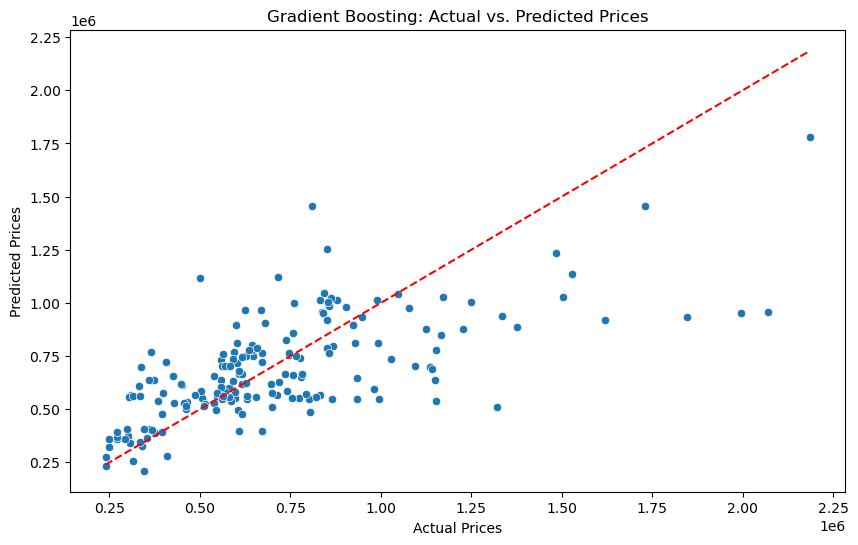

In [41]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Use the trained gbr_model to make predictions on the X_test dataset
y_pred_gbr = gbr_model.predict(X_test)

# 2. Calculate Mean Absolute Error (MAE)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)

# 3. Calculate Mean Squared Error (MSE)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)

# 4. Calculate Root Mean Squared Error (RMSE)
rmse_gbr = np.sqrt(mse_gbr)

# 5. Calculate R-squared score
r2_gbr = r2_score(y_test, y_pred_gbr)

# 6. Print all calculated evaluation metrics
print(f"Gradient Boosting - Mean Absolute Error (MAE): {mae_gbr:.2f}")
print(f"Gradient Boosting - Mean Squared Error (MSE): {mse_gbr:.2f}")
print(f"Gradient Boosting - Root Mean Squared Error (RMSE): {rmse_gbr:.2f}")
print(f"Gradient Boosting - R-squared (R2 Score): {r2_gbr:.2f}")

# 7. Create a scatter plot to visualize actual vs. predicted prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_gbr)

# 8. Add a title to the scatter plot
plt.title('Gradient Boosting: Actual vs. Predicted Prices')

# 9. Label the x-axis and y-axis
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

# 10. Add a diagonal red dashed line for perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

# 11. Display the plot
plt.show()

<!-- Compare Model Performances -->
Subtask:
Summarize and compare the performance metrics (MAE, MSE, RMSE, R-squared) of all trained models (Linear Regression, Random Forest, and Gradient Boosting) to identify the best-performing model for this dataset.

To summarize and compare the performance metrics, I will create a Pandas DataFrame that stores the MAE, MSE, RMSE, and R-squared values for each of the trained models (Linear Regression, Random Forest, and Gradient Boosting), then display this DataFrame.

In [42]:
import pandas as pd

# Create a dictionary to store the metrics
metrics_data = {
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE': [mae, mae_rf, mae_gbr],
    'MSE': [mse, mse_rf, mse_gbr],
    'RMSE': [rmse, rmse_rf, rmse_gbr],
    'R-squared': [r2, r2_rf, r2_gbr]
}

# Create a DataFrame from the metrics dictionary
performance_df = pd.DataFrame(metrics_data)

# Display the DataFrame
print("Model Performance Comparison:")
print(performance_df)

Model Performance Comparison:
               Model            MAE           MSE           RMSE  R-squared
0  Linear Regression  194708.429122  6.980540e+10  264207.117459   0.434740
1      Random Forest  198551.808333  8.132945e+10  285183.178688   0.341422
2  Gradient Boosting  181196.731568  6.734309e+10  259505.479426   0.454679


 <!-- Data Analysis Key Findings -->

*   **Random Forest Regressor Performance**: The Random Forest model achieved a Mean Absolute Error (MAE) of 198,551.81, Mean Squared Error (MSE) of 81,329,445,406.58, Root Mean Squared Error (RMSE) of 285,183.18, and an R-squared (\(R^2\)) score of 0.34 on the test set.
*   **Gradient Boosting Regressor Performance**: The Gradient Boosting model showed better performance with an MAE of 181,196.73, MSE of 67,343,093,851.96, RMSE of 259,505.48, and an \(R^2\) score of 0.45 on the test set.
*   **Model Comparison**:
    *   **Linear Regression**: MAE: 194,708.43, MSE: 69,800,000,000, RMSE: 264,207.12, \(R^2\): 0.43.
    *   **Random Forest**: MAE: 198,551.81, MSE: 81,300,000,000, RMSE: 285,183.18, \(R^2\): 0.34.
    *   **Gradient Boosting**: MAE: 181,196.73, MSE: 67,300,000,000, RMSE: 259,505.48, \(R^2\): 0.45.
*   **Best Performing Model**: The Gradient Boosting Regressor emerged as the best-performing model, exhibiting the lowest MAE, MSE, and RMSE, and the highest \(R^2\) score among the three models evaluated.

Task
Save the trained gbr_model to a file named "gradient_boosting_model.joblib" using joblib.

To save the trained gbr_model as instructed, I need to import the joblib library and then use joblib.dump() to serialize and save the model to the specified file path

In [43]:
import joblib

# Save the trained gbr_model
joblib.dump(gbr_model, 'gradient_boosting_model.joblib')

print("Gradient Boosting model saved successfully as 'gradient_boosting_model.joblib'")

Gradient Boosting model saved successfully as 'gradient_boosting_model.joblib'


Create a Prediction Function
Subtask:
Define a Python function that encapsulates the logic for making predictions. This function should load the saved model and take new input data (already preprocessed to match the training data format) to return price predictions.

In [44]:
import joblib
import pandas as pd

def predict_price(new_data: pd.DataFrame) -> np.ndarray:
    """
    Loads the trained Gradient Boosting model and makes price predictions on new data.

    Args:
        new_data (pd.DataFrame): A DataFrame containing the preprocessed input features
                                 for which to predict prices. The columns must match the
                                 training data format (X.columns).

    Returns:
        np.ndarray: An array of predicted prices.
    """
    # Load the saved Gradient Boosting model
    loaded_model = joblib.load('gradient_boosting_model.joblib')

    # Make predictions
    predictions = loaded_model.predict(new_data)

    return predictions

print("Prediction function 'predict_price' defined successfully.")

Prediction function 'predict_price' defined successfully.


<!-- Test the Prediction Function -->
Test the newly created prediction function with a sample of data, perhaps from X_test, to ensure it correctly loads the model and produces predictions as expected.


In [45]:
import pandas as pd

# 1. Select a small sample (e.g., the first 5 rows) from the X_test DataFrame
sample_data = X_test.head(5).copy()

# 2. Call the predict_price function with this sample data
sample_predictions = predict_price(sample_data)

# 3. Print the sample input data and the corresponding predicted prices
print("Sample Input Data (X_test.head(5)):")
print(sample_data)
print("\nPredicted Prices for Sample Data:")
print(sample_predictions)

Sample Input Data (X_test.head(5)):
     km_driven  year  transmission_Manual  owner_type_2nd Owner  \
332      15569  2018                 True                 False   
811       8736  2018                 True                 False   
744      26285  2014                 True                 False   
244      35131  2020                False                  True   
39       50384  2013                 True                 False   

     fuel_type_Diesel  fuel_type_Petrol  
332             False              True  
811             False              True  
744             False              True  
244             False              True  
39              False              True  

Predicted Prices for Sample Data:
[554665.69154295 327597.87888423 395919.32021102 858162.38373836
 359834.51676475]


Summary:
<!-- Data Analysis Key Findings -->
The trained gbr_model was successfully saved to a file named 'gradient_boosting_model.joblib' using the joblib.dump() function, confirming its readiness for persistence.
A Python function, predict_price, was defined to encapsulate the prediction logic. This function is capable of loading the 'gradient_boosting_model.joblib' and making predictions on new, preprocessed input data provided as a Pandas DataFrame.
The predict_price function was successfully tested using a sample of 5 rows from the X_test dataset, which confirmed that it correctly loads the model and produces expected price predictions.
<!-- Insights -->
The model is now successfully serialized and a robust prediction interface has been established, indicating that the model is ready for integration into an application or API.